In [1]:
import os, numpy as np, pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# kalau kamu pakai seaborn
import seaborn as sns

In [2]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE & PERSIAPAN DATA
# ==========================================


# --- KONFIGURASI FOLDER ---
# Pastikan path ini sesuai dengan di Drive Anda
base_dir = 'data testing terbaru'

# List Variasi dan Kualitas sesuai struktur folder Anda
qualities = ['Segar', "Tidak Segar"]
print("Sedang memindai file dan membuat label...")

data_list = []

# Loop untuk membaca file dari struktur folder
for quality in qualities:

    # Menyusun path: .../TANPA LEMPUK/GOOD/Variasi 1
    folder_path = os.path.join(base_dir, quality)
        
    if os.path.exists(folder_path):
        files = os.listdir(folder_path)
        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                # Membuat Label: "Variasi 1 GOOD", dst.
                label_name = f"{quality}" 
                full_path = os.path.join(folder_path, file_name)
                data_list.append({'filepath': full_path, 'label': label_name})
    else:
        print(f"Warning: Folder tidak ditemukan -> {folder_path}")

# Konversi ke DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal Data Ditemukan: {len(df)}")
print(f"Jumlah Kelas: {df['label'].nunique()}")

# Cek distribusi data
print("\nJumlah data per kelas:")
print(df['label'].value_counts())

# urutan kelas yang kamu mau
class_names = [f"{q}"for q in qualities]

Sedang memindai file dan membuat label...

Total Data Ditemukan: 45
Jumlah Kelas: 2

Jumlah data per kelas:
label
Tidak Segar    23
Segar          22
Name: count, dtype: int64


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (224, 224)  # samakan dengan training kamu
BATCH_SIZE = 32

# preprocessing: sesuaikan dengan backbone kamu saat training
# DenseNet biasanya pakai preprocess_input dari tf.keras.applications.densenet
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",  # ✅ harus string
    classes=class_names, 
    shuffle=False
)

    
print(class_names)

Found 45 validated image filenames belonging to 2 classes.
['Segar', 'Tidak Segar']


In [4]:
import tensorflow as tf

MODEL_PATH = "Exp2_DenseNet121_Texture_best_model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded:", MODEL_PATH)

Model loaded: Exp2_DenseNet121_Texture_best_model.keras


C:\Users\Azvadennys\Desktop\Training Edible Film\venv-39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
              precision    recall  f1-score   support

       Segar     1.0000    0.1818    0.3077        22
 Tidak Segar     0.5610    1.0000    0.7188        23

    accuracy                         0.6000        45
   macro avg     0.7805    0.5909    0.5132        45
weighted avg     0.7756    0.6000    0.5178        45



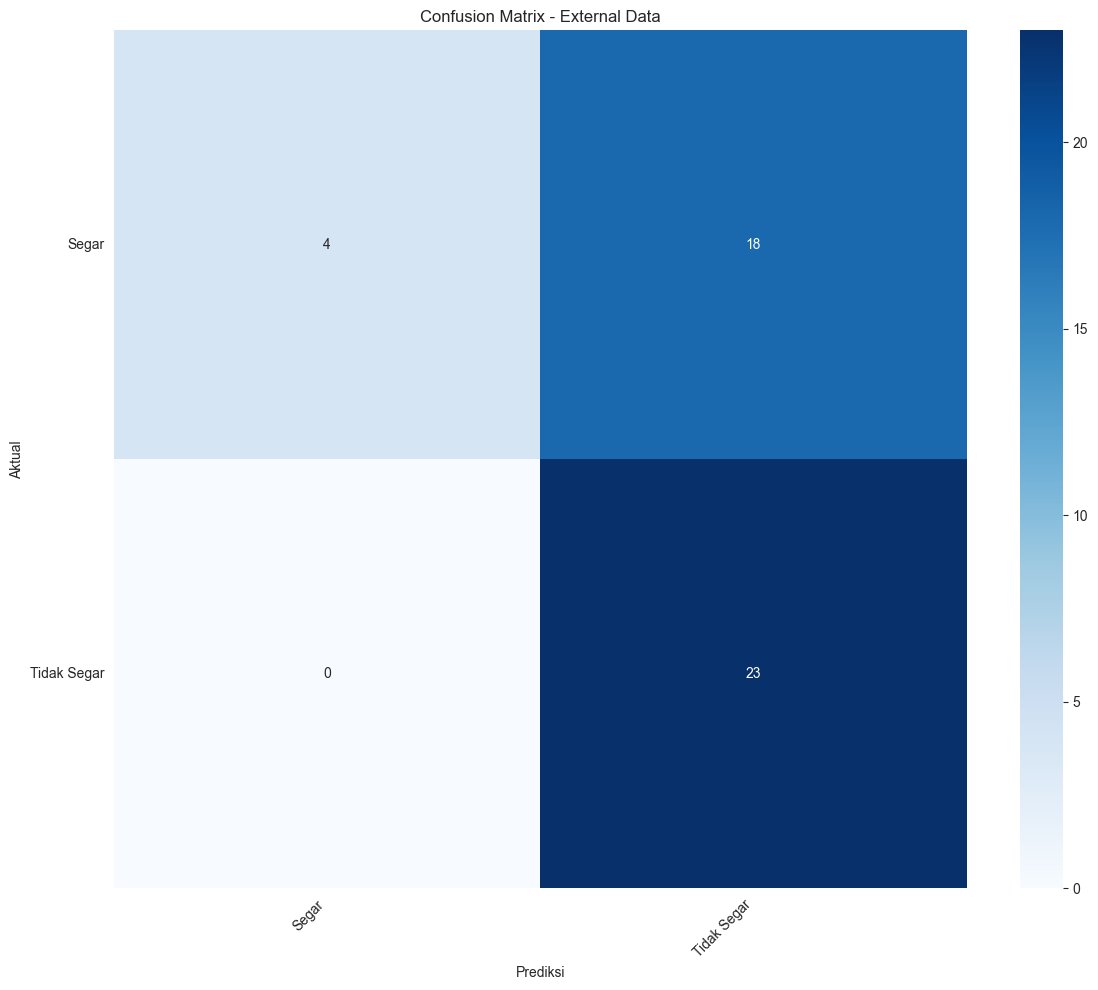

In [5]:
# prediksi
pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes  # sudah sesuai urutan data karena shuffle=False

# report
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - External Data")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()